1. DATA LOADING AND VALIDATION
Loading CO2 dataset from Our World in Data...
Dataset successfully loaded.

Dataset Shape: 50,411 rows, 79 columns

Unique Countries: 218
Year Range: 1750 to 2024
Analysis Period: 2015 to 2024

2. DATA PREPROCESSING AND FILTERING
Selected top 50 CO2 emitters as of 2024.
Derived indicators: Emissions_Intensity, Year_over_Year_Change_Pct, Decarbonization_Rate

3. GLOBAL EMISSIONS ANALYSIS
Global CO2 (2024): 38,598.58 Million Tonnes
Global CO2 Per Capita: 4.73 Tonnes/Person
Year-over-Year Change: +1.32%

Top 15 Largest Emitters (2024):
      Country  CO2_Emissions_Mt  CO2_Per_Capita  YoY_Change_Pct
        China       12,289.0400          8.6600          0.9600
United States        4,904.1200         14.2000         -0.2900
        India        3,193.4800          2.2000          4.2700
       Russia        1,780.5200         12.3000          2.7300
        Japan          961.8700          7.7700         -2.5400
    Indonesia          812.2200          2.860

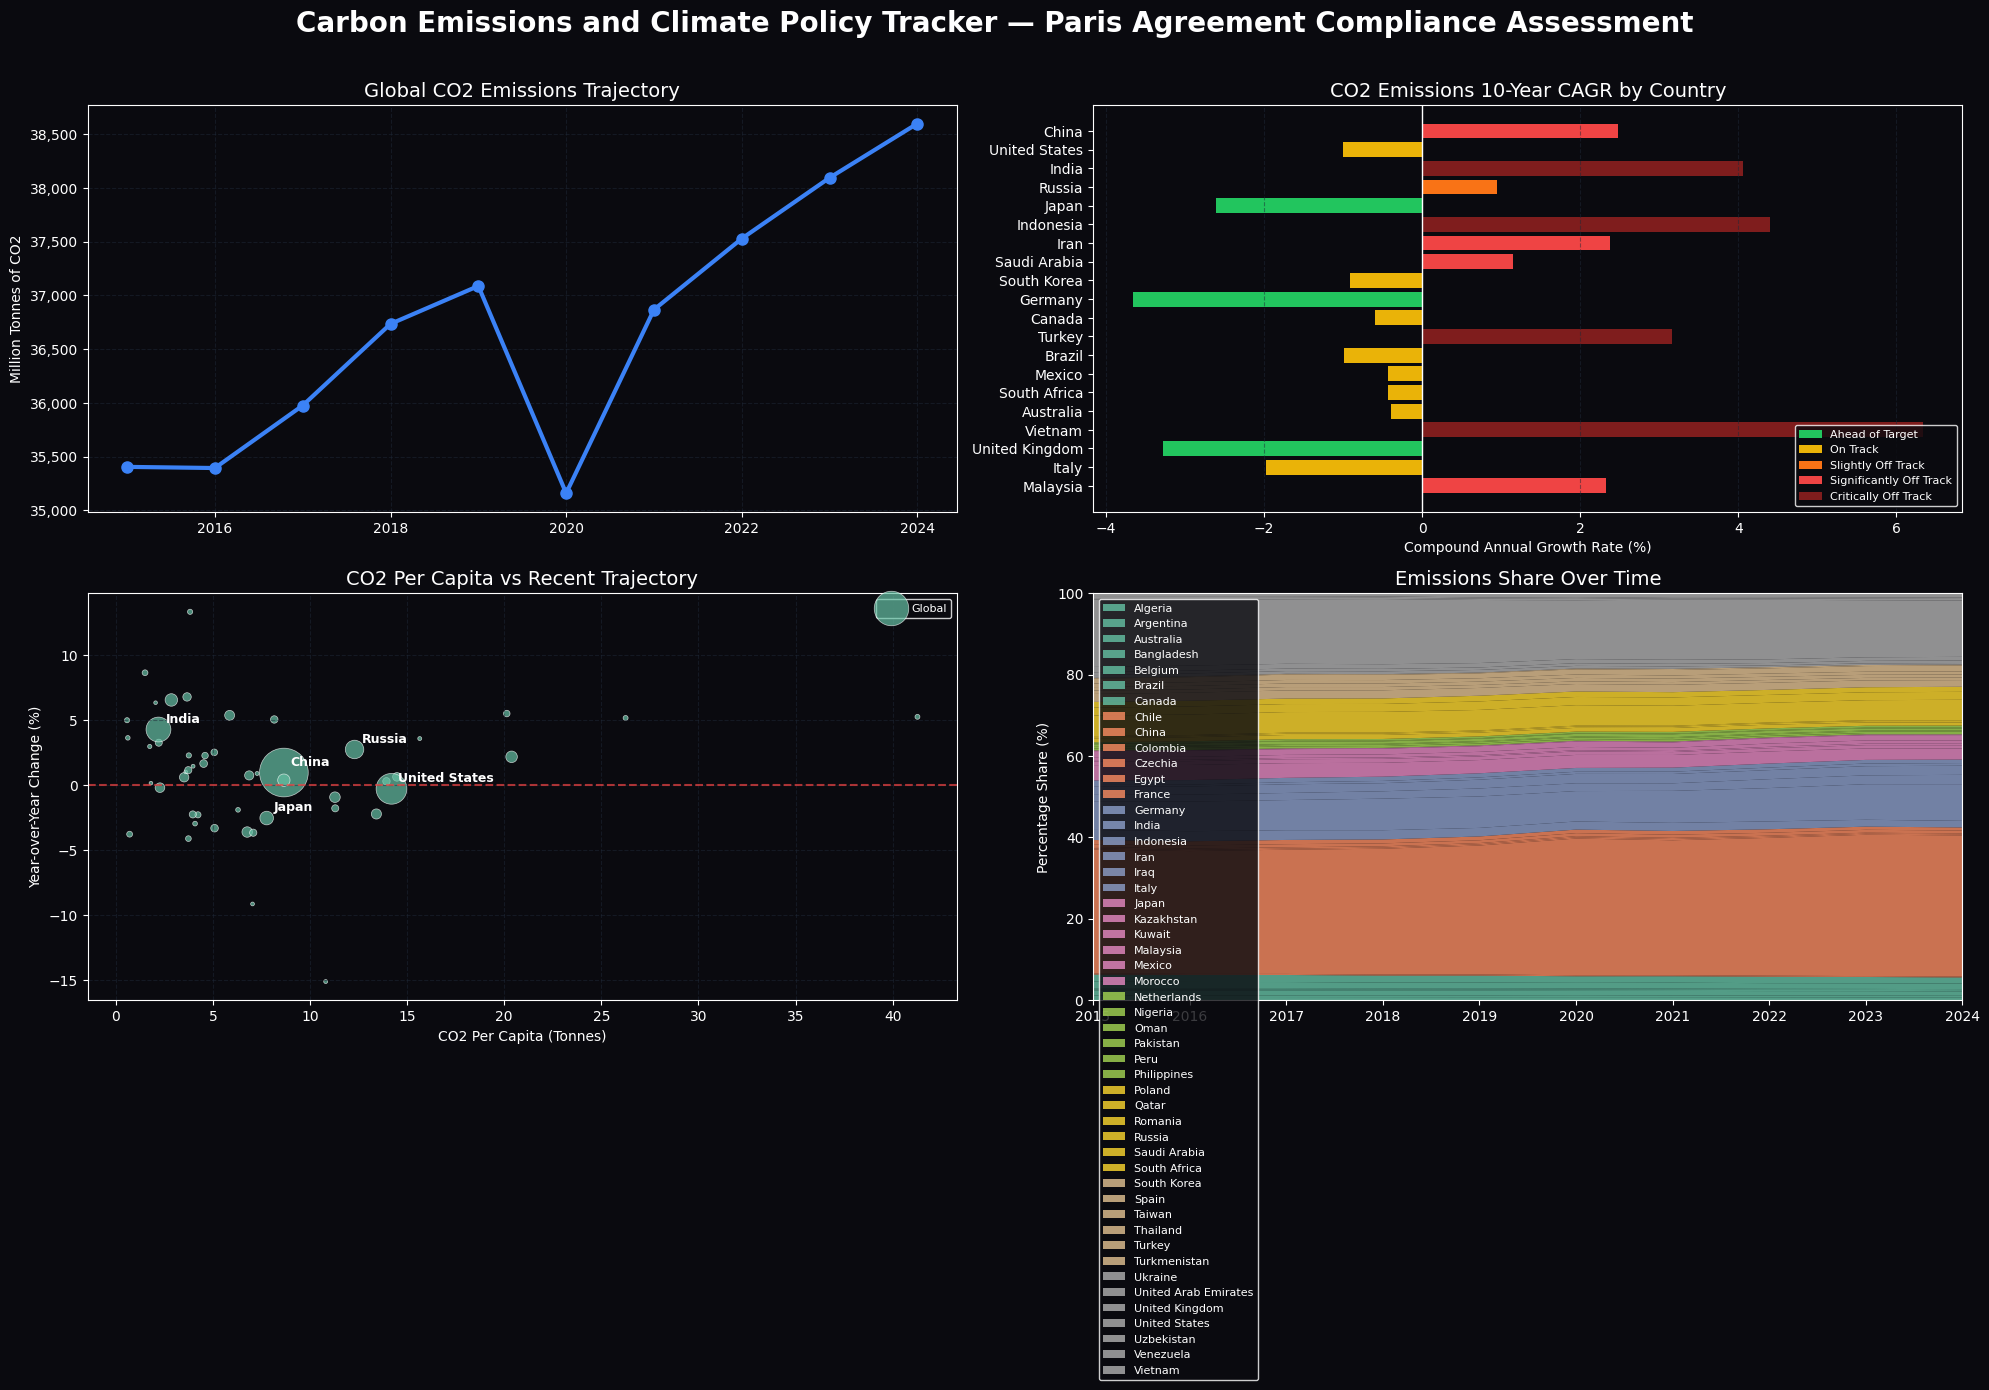


7. INTERACTIVE GLOBAL EMISSIONS MAP



8. ANALYTICAL EXPORTS
Exported carbon_emissions_tracker.csv (500 rows)
Exported paris_compliance_summary.csv (50 countries)

PIPELINE COMPLETE


In [9]:
# ==============================================================================
# CARBON EMISSIONS AND CLIMATE POLICY COMPLIANCE TRACKER
# Target Audience: COP Summit Delegation, Sovereign Wealth Funds, Central Banks
# Objective: Assess global decarbonization trajectories, Paris Agreement
#            alignment, and absolute decoupling of GDP and CO2 emissions
# Data: Our World in Data CO2 and Greenhouse Gas Emissions (real data)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.style.use('dark_background')

print("="*80)
print("1. DATA LOADING AND VALIDATION")
print("="*80)

url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
print(f"Loading CO2 dataset from Our World in Data...")

try:
    df_raw = pd.read_csv(url)
    print("Dataset successfully loaded.")
except Exception as e:
    print(f"Data load failed. Details: {type(e).__name__}")
    print("Please check your internet connection and try again.")
    import sys
    sys.exit()

print(f"\nDataset Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]:,} columns")

# Filter to country-level data only
countries_only = df_raw[df_raw['iso_code'].notnull()].copy()
countries_only = countries_only[
    ~countries_only['iso_code'].str.startswith('OWID_') | (countries_only['iso_code'] == 'OWID_KOS')
]

unique_countries = countries_only['iso_code'].nunique()
min_yr, max_yr = int(df_raw['year'].min()), int(df_raw['year'].max())

reporting_counts = countries_only.dropna(subset=['co2']).groupby('year').size()
complete_years = reporting_counts[reporting_counts > 150].index
most_recent_complete_year = int(complete_years.max())

# Get world aggregate data - try multiple possible codes, fall back to calculation
world_all = df_raw[
    (df_raw['iso_code'].isin(['OWID_WRL', 'OWID_WLD'])) |
    (df_raw['country'].isin(['World', 'World Population']))
].sort_values('year')

if len(world_all) == 0:
    world_all = countries_only.groupby('year').agg(
        co2=('co2', 'sum'),
        co2_per_capita=('co2_per_capita', 'mean'),
        population=('population', 'sum')
    ).reset_index()

world_available_years = [int(y) for y in world_all['year'].dropna().tolist()]

while most_recent_complete_year not in world_available_years and most_recent_complete_year > 2000:
    most_recent_complete_year -= 1

start_year = most_recent_complete_year - 9

world_data = world_all[(world_all['year'] >= start_year) & (world_all['year'] <= most_recent_complete_year)]

if len(world_data) < 2:
    raise RuntimeError(f"Not enough world data. Found {len(world_data)} years.")

world_recent = world_data[world_data['year'] == most_recent_complete_year].iloc[0]
world_prev = world_data[world_data['year'] == (most_recent_complete_year - 1)].iloc[0]

print(f"\nUnique Countries: {unique_countries}")
print(f"Year Range: {min_yr} to {max_yr}")
print(f"Analysis Period: {start_year} to {most_recent_complete_year}")

# ==============================================================================
# 2. DATA PREPROCESSING AND FILTERING
# ==============================================================================
print("\n" + "="*80)
print("2. DATA PREPROCESSING AND FILTERING")
print("="*80)

df_10y = countries_only[(countries_only['year'] >= start_year) &
                        (countries_only['year'] <= most_recent_complete_year)]

recent_year_data = df_10y[df_10y['year'] == most_recent_complete_year]
top_50_iso = recent_year_data.nlargest(50, 'co2')['iso_code'].tolist()

print(f"Selected top 50 CO2 emitters as of {most_recent_complete_year}.")
df_top50 = df_10y[df_10y['iso_code'].isin(top_50_iso)].copy()

desired_cols = [
    'country', 'iso_code', 'continent', 'year', 'population', 'gdp',
    'co2', 'co2_per_capita', 'total_ghg', 'methane', 'nitrous_oxide',
    'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2',
    'energy_per_capita', 'carbon_intensity_elec', 'share_global_co2', 'cumulative_co2'
]
available_cols = [c for c in desired_cols if c in df_top50.columns]
if 'continent' not in available_cols and 'continent' in df_top50.columns:
    available_cols.append('continent')
df_top50 = df_top50[available_cols]

if 'gdp' in df_top50.columns:
    df_top50['Emissions_Intensity'] = df_top50['co2'] / (df_top50['gdp'] / 1e9)
else:
    df_top50['Emissions_Intensity'] = np.nan

df_top50.sort_values(by=['iso_code', 'year'], inplace=True)
df_top50['Year_over_Year_Change_Pct'] = df_top50.groupby('iso_code')['co2'].pct_change() * 100
df_top50['Decarbonization_Rate'] = -df_top50.groupby('iso_code')['Emissions_Intensity'].pct_change() * 100

print("Derived indicators: Emissions_Intensity, Year_over_Year_Change_Pct, Decarbonization_Rate")

# ==============================================================================
# 3. GLOBAL EMISSIONS ANALYSIS
# ==============================================================================
print("\n" + "="*80)
print("3. GLOBAL EMISSIONS ANALYSIS")
print("="*80)

global_co2 = world_recent['co2']
global_co2_pc = world_recent['co2_per_capita']
global_yoy = ((global_co2 / world_prev['co2']) - 1) * 100 if world_prev['co2'] > 0 else 0

print(f"Global CO2 ({most_recent_complete_year}): {global_co2:,.2f} Million Tonnes")
print(f"Global CO2 Per Capita: {global_co2_pc:,.2f} Tonnes/Person")
print(f"Year-over-Year Change: {global_yoy:+.2f}%")

print(f"\nTop 15 Largest Emitters ({most_recent_complete_year}):")
recent_top50 = df_top50[df_top50['year'] == most_recent_complete_year]
top15 = recent_top50.nlargest(15, 'co2')[['country', 'co2', 'co2_per_capita', 'Year_over_Year_Change_Pct']]
top15.columns = ['Country', 'CO2_Emissions_Mt', 'CO2_Per_Capita', 'YoY_Change_Pct']
print(top15.round(2).to_string(index=False))

print("\nGlobal Emissions Trend:")
trend_table = world_data[['year', 'co2']].copy()
trend_table['YoY_Change_Pct'] = trend_table['co2'].pct_change() * 100
trend_table.columns = ['Year', 'CO2_Mt', 'YoY_Change_Pct']
print(trend_table.round(2).to_string(index=False))

# ==============================================================================
# 4. PARIS AGREEMENT COMPLIANCE FRAMEWORK
# ==============================================================================
print("\n" + "="*80)
print("4. PARIS AGREEMENT COMPLIANCE FRAMEWORK")
print("="*80)

def calculate_cagr(start_val, end_val, periods=9):
    if start_val is None or end_val is None:
        return np.nan
    if start_val <= 0 or pd.isna(start_val) or pd.isna(end_val):
        return np.nan
    return ((end_val / start_val) ** (1/periods) - 1) * 100

start_data = df_top50[df_top50['year'] == start_year][['iso_code', 'co2', 'gdp']]
end_data = df_top50[df_top50['year'] == most_recent_complete_year][['iso_code', 'country', 'co2', 'gdp']]

compliance_df = pd.merge(start_data, end_data, on='iso_code', suffixes=('_start', '_end'))
periods = most_recent_complete_year - start_year
compliance_df['CO2_CAGR'] = compliance_df.apply(
    lambda row: calculate_cagr(row['co2_start'], row['co2_end'], periods), axis=1
)
if 'gdp_start' in compliance_df.columns:
    compliance_df['GDP_CAGR'] = compliance_df.apply(
        lambda row: calculate_cagr(row['gdp_start'], row['gdp_end'], periods), axis=1
    )

def classify_compliance(cagr):
    if pd.isna(cagr): return "Insufficient Data"
    if cagr < -2.0: return "Ahead of Target"
    elif cagr <= 0.0: return "On Track"
    elif cagr <= 1.0: return "Slightly Off Track"
    elif cagr <= 3.0: return "Significantly Off Track"
    else: return "Critically Off Track"

compliance_df['Compliance_Status'] = compliance_df['CO2_CAGR'].apply(classify_compliance)

status_order = ["Ahead of Target", "On Track", "Slightly Off Track", "Significantly Off Track", "Critically Off Track", "Insufficient Data"]
compliance_df['Compliance_Status'] = pd.Categorical(compliance_df['Compliance_Status'], categories=status_order, ordered=True)
compliance_df = compliance_df.sort_values(['Compliance_Status', 'CO2_CAGR'])

print("\nParis Agreement Compliance (sorted by status):")
print(compliance_df[['country', 'CO2_CAGR', 'Compliance_Status']].round(2).to_string(index=False))

print("\nCompliance Summary:")
summary_counts = compliance_df['Compliance_Status'].value_counts().reset_index()
summary_counts.columns = ['Status', 'Count']
summary_counts['Percentage'] = (summary_counts['Count'] / len(compliance_df)) * 100
print(summary_counts.to_string(index=False))

df_top50 = pd.merge(df_top50, compliance_df[['iso_code', 'Compliance_Status', 'CO2_CAGR']], on='iso_code', how='left')

# ==============================================================================
# 5. DECARBONIZATION ANALYSIS
# ==============================================================================
print("\n" + "="*80)
print("5. DECARBONIZATION ANALYSIS")
print("="*80)

avg_decarb = df_top50.groupby(['iso_code', 'country'])['Decarbonization_Rate'].mean().reset_index()
avg_decarb = avg_decarb.sort_values('Decarbonization_Rate', ascending=False).dropna()

print("\nTop 15 Countries by Decarbonization Rate (positive = improving):")
print(avg_decarb.head(15).round(2).to_string(index=False))

print("\nBottom 10 Countries (increasing carbon intensity):")
print(avg_decarb.tail(10).round(2).to_string(index=False))

print("\nAbsolute Decoupling Champions (GDP growth with CO2 decline):")
if 'GDP_CAGR' in compliance_df.columns:
    decoupled = compliance_df[(compliance_df['GDP_CAGR'] > 0) & (compliance_df['CO2_CAGR'] < 0)]
    decoupled = decoupled.sort_values('CO2_CAGR')
    if not decoupled.empty:
        print(decoupled[['country', 'GDP_CAGR', 'CO2_CAGR', 'Compliance_Status']].round(2).to_string(index=False))
    else:
        print("No countries in the Top 50 achieved absolute decoupling over this period.")

# ==============================================================================
# 6. EXECUTIVE DASHBOARD
# ==============================================================================
print("\n" + "="*80)
print("6. EXECUTIVE DASHBOARD")
print("="*80)

fig, axs = plt.subplots(2, 2, figsize=(20, 14), facecolor='#0a0a0f')
fig.suptitle('Carbon Emissions and Climate Policy Tracker — Paris Agreement Compliance Assessment',
             fontsize=20, fontweight='bold', color='white', y=0.96)
fig.patch.set_facecolor('#0a0a0f')

status_colors = {
    "Ahead of Target": "#22c55e",
    "On Track": "#eab308",
    "Slightly Off Track": "#f97316",
    "Significantly Off Track": "#ef4444",
    "Critically Off Track": "#7f1d1d",
    "Insufficient Data": "#6b7280"
}

ax1 = axs[0, 0]
ax1.set_facecolor('#0a0a0f')
ax1.plot(world_data['year'], world_data['co2'], color='#3b82f6', marker='o', linewidth=3, markersize=8)
ax1.set_title('Global CO2 Emissions Trajectory', color='white', fontsize=14)
ax1.set_ylabel('Million Tonnes of CO2', color='white')
ax1.tick_params(colors='white')
ax1.grid(color='#1f2937', linestyle='--', alpha=0.5)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2 = axs[0, 1]
ax2.set_facecolor('#0a0a0f')
top20_isos = recent_top50.nlargest(20, 'co2')['iso_code']
top20_comp = compliance_df[compliance_df['iso_code'].isin(top20_isos)].sort_values('co2_end', ascending=True)
bars = ax2.barh(top20_comp['country'], top20_comp['CO2_CAGR'],
                color=[status_colors.get(s, '#6b7280') for s in top20_comp['Compliance_Status']])
ax2.axvline(x=0, color='white', linewidth=1)
ax2.set_title('CO2 Emissions 10-Year CAGR by Country', color='white', fontsize=14)
ax2.set_xlabel('Compound Annual Growth Rate (%)', color='white')
ax2.tick_params(colors='white')
ax2.grid(axis='x', color='#1f2937', linestyle='--', alpha=0.5)
legend_elements = [Patch(facecolor=c, label=l) for l, c in status_colors.items() if l != "Insufficient Data"]
ax2.legend(handles=legend_elements, loc='lower right', facecolor='#0a0a0f', edgecolor='white', labelcolor='white', fontsize=8)

ax3 = axs[1, 0]
ax3.set_facecolor('#0a0a0f')
scatter_data = recent_top50.dropna(subset=['co2_per_capita', 'Year_over_Year_Change_Pct', 'co2']).copy()
if 'continent' in scatter_data.columns:
    group_col = 'continent'
else:
    scatter_data['continent'] = 'Global'
    group_col = 'continent'

continents = scatter_data[group_col].unique()
cmap = plt.cm.Set2
colors = cmap(np.linspace(0, 1, len(continents)))
for i, cont in enumerate(continents):
    subset = scatter_data[scatter_data[group_col] == cont]
    ax3.scatter(subset['co2_per_capita'], subset['Year_over_Year_Change_Pct'],
                s=subset['co2']/10, c=[colors[i]], label=cont, alpha=0.7, edgecolors='white', linewidth=0.5)
for _, row in scatter_data.nlargest(5, 'co2').iterrows():
    ax3.annotate(row['country'], (row['co2_per_capita'], row['Year_over_Year_Change_Pct']),
                 xytext=(5, 5), textcoords='offset points', color='white', fontsize=9, fontweight='bold')
ax3.axhline(y=0, color='#ef4444', linestyle='--', alpha=0.7)
ax3.set_title(f'CO2 Per Capita vs Recent Trajectory', color='white', fontsize=14)
ax3.set_xlabel('CO2 Per Capita (Tonnes)', color='white')
ax3.set_ylabel('Year-over-Year Change (%)', color='white')
ax3.tick_params(colors='white')
ax3.grid(color='#1f2937', linestyle='--', alpha=0.5)
ax3.legend(facecolor='#0a0a0f', edgecolor='white', labelcolor='white', fontsize=8)

ax4 = axs[1, 1]
ax4.set_facecolor('#0a0a0f')
group_col2 = 'continent' if 'continent' in df_top50.columns else 'country'
pivot_df = df_top50.pivot_table(index='year', columns=group_col2, values='co2', aggfunc='sum')
pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100
ax4.stackplot(pivot_pct.index, pivot_pct.T.values, labels=pivot_pct.columns, alpha=0.8, colors=cmap(np.linspace(0, 1, len(pivot_pct.columns))))
ax4.set_title('Emissions Share Over Time', color='white', fontsize=14)
ax4.set_ylabel('Percentage Share (%)', color='white')
ax4.tick_params(colors='white')
ax4.set_xlim(start_year, most_recent_complete_year)
ax4.set_ylim(0, 100)
ax4.legend(loc='upper left', facecolor='#0a0a0f', edgecolor='white', labelcolor='white', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ==============================================================================
# 7. INTERACTIVE GLOBAL EMISSIONS MAP
# ==============================================================================
print("\n" + "="*80)
print("7. INTERACTIVE GLOBAL EMISSIONS MAP")
print("="*80)

map_data = df_top50[df_top50['year'] == most_recent_complete_year].copy()
if 'Compliance_Status' not in map_data.columns:
    map_data = map_data.merge(compliance_df[['iso_code', 'Compliance_Status']], on='iso_code', how='left')
map_data['YoY_Text'] = map_data['Year_over_Year_Change_Pct'].apply(lambda x: f"{x:+.2f}%" if pd.notnull(x) else "N/A")
map_data['CO2_Text'] = map_data['co2'].apply(lambda x: f"{x:,.1f} Mt")

fig_map = px.choropleth(
    map_data, locations="iso_code", color="co2_per_capita",
    hover_name="country",
    hover_data={"iso_code": False, "CO2_Text": True, "co2_per_capita": ":.2f", "YoY_Text": True, "Compliance_Status": True},
    color_continuous_scale="OrRd",
    title=f"Global CO2 Emissions Per Capita ({most_recent_complete_year})",
    labels={'co2_per_capita': 'CO2 Per Capita (Tonnes)'}
)
fig_map.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular', bgcolor='#0a0a0f', coastlinecolor='grey', landcolor='#1a1a2e'),
    paper_bgcolor='#0a0a0f', plot_bgcolor='#0a0a0f', font=dict(color='white'), title_font=dict(size=20)
)
fig_map.show()

# ==============================================================================
# 8. ANALYTICAL EXPORTS
# ==============================================================================
print("\n" + "="*80)
print("8. ANALYTICAL EXPORTS")
print("="*80)

df_top50.to_csv("carbon_emissions_tracker.csv", index=False)
compliance_df.to_csv("paris_compliance_summary.csv", index=False)

print(f"Exported carbon_emissions_tracker.csv ({len(df_top50):,} rows)")
print(f"Exported paris_compliance_summary.csv ({len(compliance_df)} countries)")
print("\nPIPELINE COMPLETE")